# 1.3 Catalog profiling

Perfilamiento de los equipos contra `catalogo_entornos` a partir de hipótesis: (1) cobertura del catálogo en ambos sentidos,
(2) consistencia de nombres, (3) jerarquía de padres, (4) vigencia de los equipos no catalogados, (5) canasta de indicadores por equipo.
Cierra con la propuesta de modelo (actividad 1.1).

Artefactos persistidos: ninguno (diagnóstico).

| Artefacto | Ruta |
|---|---|
| Entrada | `data/0_source/KPIS_historico.xlsx` (hojas `query`, `catalogo_entornos`) |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)

SOURCE_PATH = Path("../../data/0_source/KPIS_historico.xlsx")

COLOR = {"verde": "#00c389", "morado": "#9063cd", "naranja": "#ff7f41", "azul": "#59cbe8", "negro": "#2a2625", "gris": "#9e9a99"}
COLOR_GRUPO = {"Entorno (ENX)": COLOR["azul"], "Vicepresidencia (VPX)": COLOR["morado"],
               "Sin entorno (catálogo)": COLOR["naranja"], "No catalogado": COLOR["gris"]}
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": COLOR["gris"], "axes.spines.top": False,
                     "axes.spines.right": False, "xtick.color": COLOR["negro"], "ytick.color": COLOR["negro"]})

HIPOTESIS = []


def registrar_hipotesis(codigo, enunciado, resultado, evidencia):
    """resultado: 'se cumple' | 'no se cumple' | 'parcial'."""
    HIPOTESIS.append({"hipotesis": codigo, "enunciado": enunciado, "resultado": resultado, "evidencia": evidencia})
    print(f"{codigo} | {resultado.upper()} | {evidencia}")


def normalizar_codigo(s):
    # Mismo criterio que H04: mayúsculas y 5 dígitos (Equ00074 -> EQU00074, EQU0024 -> EQU00024)
    return s.str.strip().str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)


query = pd.read_excel(SOURCE_PATH, sheet_name="query", dtype=str).drop_duplicates()
query["codigo"] = normalizar_codigo(query.Codigo_EQU)
query = query.dropna(subset=["codigo"])

cat_ent = pd.read_excel(SOURCE_PATH, sheet_name="catalogo_entornos", dtype=str)
cat_ent["grupo_padre"] = np.select(
    [cat_ent.Codigo_Padre.str.startswith("ENX"), cat_ent.Codigo_Padre.str.startswith("VPX")],
    ["Entorno (ENX)", "Vicepresidencia (VPX)"], default="Sin entorno (catálogo)",
)
query = query.merge(cat_ent[["Codigo_EQU", "EQU", "Codigo_Padre", "Nombre_Padre", "grupo_padre"]],
                    left_on="codigo", right_on="Codigo_EQU", how="left", suffixes=("", "_cat"))
query["grupo_padre"] = query.grupo_padre.fillna("No catalogado")
print("query | filas:", len(query), "| equipos:", query.codigo.nunique(), "| catálogo:", len(cat_ent), "equipos")


query | filas: 12970 | equipos: 89 | catálogo: 64 equipos


## H18. Todos los equipos de los datos están en `catalogo_entornos`


In [2]:
equipos_datos, equipos_cat = set(query.codigo), set(cat_ent.Codigo_EQU)
no_cat = equipos_datos - equipos_cat
filas_no_cat = query.codigo.isin(no_cat).sum()
registrar_hipotesis(
    "H18", "Todos los equipos de los datos están en catalogo_entornos",
    "se cumple" if not no_cat else "no se cumple",
    f"{len(no_cat)} de {len(equipos_datos)} equipos sin catalogar ({filas_no_cat} filas, {filas_no_cat / len(query):.1%})",
)


H18 | NO SE CUMPLE | 26 de 89 equipos sin catalogar (1417 filas, 10.9%)


## H19. Todos los equipos del catálogo tienen mediciones


In [3]:
sin_mediciones = sorted(equipos_cat - equipos_datos)
registrar_hipotesis(
    "H19", "Todos los equipos del catálogo tienen mediciones",
    "se cumple" if not sin_mediciones else "no se cumple",
    f"{len(sin_mediciones)} equipo(s) sin mediciones: {', '.join(sin_mediciones)}",
)


H19 | NO SE CUMPLE | 1 equipo(s) sin mediciones: EQU00023


## H20. Los nombres de equipo coinciden con el catálogo


In [4]:
con_nombre = query.dropna(subset=["EQU", "EQU_cat"])
distintos = con_nombre[con_nombre.EQU != con_nombre.EQU_cat].codigo.nunique()
registrar_hipotesis(
    "H20", "Los nombres de equipo coinciden con el catálogo",
    "se cumple" if distintos == 0 else "no se cumple",
    f"{distintos} equipos con nombre distinto al catálogo ({len(con_nombre)} filas comparables)",
)


H20 | SE CUMPLE | 0 equipos con nombre distinto al catálogo (7114 filas comparables)


## H21. Todo equipo del catálogo pertenece a un entorno


In [5]:
jerarquia = cat_ent.groupby(["grupo_padre", "Codigo_Padre"]).Codigo_EQU.count().rename("equipos").reset_index()
display(jerarquia.groupby("grupo_padre").agg(padres=("Codigo_Padre", "nunique"), equipos=("equipos", "sum")))
fuera_entorno = cat_ent[cat_ent.grupo_padre != "Entorno (ENX)"]
registrar_hipotesis(
    "H21", "Todo equipo del catálogo pertenece a un entorno (ENX)",
    "se cumple" if fuera_entorno.empty else "no se cumple",
    f"{len(fuera_entorno)} equipos fuera de un entorno: {fuera_entorno.grupo_padre.value_counts().to_dict()}; "
    f"{(jerarquia.equipos == 1).sum()} de {len(jerarquia)} padres tienen un solo equipo",
)


,padres,equipos
grupo_padre,,
Entorno (ENX),16,50
Sin entorno (catálogo),2,2
Vicepresidencia (VPX),8,12


H21 | NO SE CUMPLE | 14 equipos fuera de un entorno: {'Vicepresidencia (VPX)': 12, 'Sin entorno (catálogo)': 2}; 10 de 26 padres tienen un solo equipo


## H22. Los equipos no catalogados son históricos (ya no reportan)

El catálogo describe los equipos **vigentes hoy**; si un equipo no catalogado dejó de reportar, es historia y no un error.


ultimo_corte,202308,202312,202404,202409,202412,202501,202509,202512,202602,202607,202608
equipos,3,5,1,1,1,3,3,1,1,4,3


H22 | PARCIAL | 18 de 26 dejaron de reportar antes de 2026 (históricos); 8 siguen activos en 2026 (vacíos del catálogo a reportar)


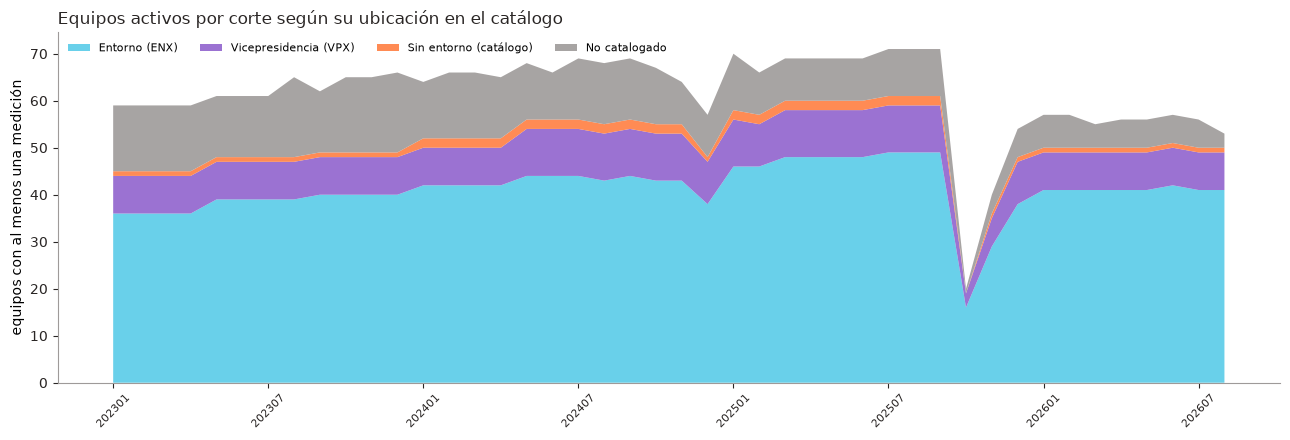

In [6]:
equipos = query.groupby("codigo").agg(grupo_padre=("grupo_padre", "first"), ultimo_corte=("Corte", "max"))
no_cat_equipos = equipos[equipos.grupo_padre == "No catalogado"]
inactivos = (no_cat_equipos.ultimo_corte < "202601").sum()
display(no_cat_equipos.ultimo_corte.value_counts().sort_index().rename("equipos").to_frame().T)
registrar_hipotesis(
    "H22", "Los equipos no catalogados son históricos (ya no reportan)",
    "parcial",
    f"{inactivos} de {len(no_cat_equipos)} dejaron de reportar antes de 2026 (históricos); "
    f"{len(no_cat_equipos) - inactivos} siguen activos en 2026 (vacíos del catálogo a reportar)",
)

activos = query.groupby(["Corte", "grupo_padre"]).codigo.nunique().unstack(fill_value=0)[list(COLOR_GRUPO)]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.stackplot(range(len(activos)), activos.T.values, labels=activos.columns, colors=list(COLOR_GRUPO.values()), alpha=0.9)
ticks = [i for i, c in enumerate(activos.index) if c.endswith(("01", "07"))]
ax.set_xticks(ticks, [activos.index[i] for i in ticks], rotation=45, fontsize=8)
ax.set_ylabel("equipos con al menos una medición")
ax.set_title("Equipos activos por corte según su ubicación en el catálogo", loc="left", color=COLOR["negro"])
ax.legend(loc="upper left", frameon=False, fontsize=8, ncol=4)
plt.tight_layout()
plt.show()


## H23. En un mismo corte todos los equipos se miden con la misma canasta de indicadores


In [7]:
canasta = query.groupby(["Corte", "codigo"]).Indicador.apply(lambda s: " | ".join(sorted(s.unique())))
canastas_por_corte = canasta.groupby(level="Corte").nunique()
indicadores_por_equipo = query.groupby(["Corte", "codigo"]).Indicador.nunique()
display(indicadores_por_equipo.groupby(level="Corte").agg(["min", "median", "max"]).describe().loc[["min", "50%", "max"]].round(1))
registrar_hipotesis(
    "H23", "En un mismo corte todos los equipos se miden con la misma canasta de indicadores",
    "se cumple" if canastas_por_corte.max() == 1 else "no se cumple",
    f"mediana de {canastas_por_corte.median():.0f} canastas distintas por corte (máx. {canastas_por_corte.max()}); "
    f"un equipo puede tener de {indicadores_por_equipo.min()} a {indicadores_por_equipo.max()} indicadores en un corte",
)


,min,median,max
min,1.0,1.0,2.0
50%,1.0,5.0,8.0
max,1.0,7.0,12.0


H23 | NO SE CUMPLE | mediana de 24 canastas distintas por corte (máx. 54); un equipo puede tener de 1 a 12 indicadores en un corte


Lectura: un ranking por promedio simple compara a un equipo medido solo con Disponibilidad (≈ 1.0 casi siempre) contra otro medido con Vulnerabilidades (0 a 1.2). **La métrica comparable debe neutralizar el efecto "qué me midieron".**


## Resumen de hipótesis


In [8]:
display(pd.DataFrame(HIPOTESIS).set_index("hipotesis"))


,enunciado,resultado,evidencia
hipotesis,,,
H18,Todos los equipos de los datos están en catalo...,no se cumple,"26 de 89 equipos sin catalogar (1417 filas, 10..."
H19,Todos los equipos del catálogo tienen mediciones,no se cumple,1 equipo(s) sin mediciones: EQU00023
H20,Los nombres de equipo coinciden con el catálogo,se cumple,0 equipos con nombre distinto al catálogo (711...
H21,Todo equipo del catálogo pertenece a un entorn...,no se cumple,14 equipos fuera de un entorno: {'Vicepresiden...
H22,Los equipos no catalogados son históricos (ya ...,parcial,18 de 26 dejaron de reportar antes de 2026 (hi...
H23,En un mismo corte todos los equipos se miden c...,no se cumple,mediana de 24 canastas distintas por corte (má...


## Propuesta de modelo (actividad 1.1)

| Tabla | Grano | Columnas |
|---|---|---|
| `hecho_kpi` | corte × equipo × indicador | `corte`, `codigo_equipo`, `indicador_id`, `resultado`, `meta`, `cumplimiento_reportado`, `cumplimiento_comparable`, banderas de calidad |
| `dim_equipo` | equipo | `codigo_equipo`, `nombre_equipo`, `tipo_equipo` (EQU/CEX), `codigo_padre`, `vigente_en_catalogo` |
| `dim_padre` | padre | `codigo_padre`, `nombre_padre`, `tipo_padre` (entorno / vicepresidencia / sin entorno) |
| `dim_indicador` | indicador | `indicador_id`, `indicador`, `frente_id`, `unidad`, `formula`, `tope`, `sentido`, `en_catalogo` |
| `dim_frente` | frente | `frente_id`, `frente` homologado, alias históricos |
| `dim_tiempo` | mes | `corte`, `fecha_corte`, `anio`, `mes` |

`dim_indicador` se alimenta de la ficha de `1_2` validada por el equipo: es donde vive la regla de negocio de cada indicador.
